In [1]:
!pip install torchinfo

>>> [1/7] Setting up Configuration...
    Device: cuda

>>> [2/7] Loading Sipakmed Dataset...
    Total images found: 4049
    Train: 2834, Val: 607, Test: 608

>>> [3/7] Building Attention Model Architecture...

>>> [4/7] Training Attention Model...
    Epoch 01 | Train Loss: 0.9347 Acc: 0.6507 | Val Loss: 0.5572 Acc: 0.7891
    Epoch 02 | Train Loss: 0.6311 Acc: 0.7632 | Val Loss: 0.3729 Acc: 0.8666
    Epoch 03 | Train Loss: 0.5409 Acc: 0.7960 | Val Loss: 0.3281 Acc: 0.8863
    Epoch 04 | Train Loss: 0.4673 Acc: 0.8260 | Val Loss: 0.2958 Acc: 0.8929
    Epoch 05 | Train Loss: 0.4301 Acc: 0.8391 | Val Loss: 0.2993 Acc: 0.8880
    Epoch 06 | Train Loss: 0.3708 Acc: 0.8652 | Val Loss: 0.2119 Acc: 0.9127
    Epoch 07 | Train Loss: 0.3337 Acc: 0.8744 | Val Loss: 0.2032 Acc: 0.9242
    Epoch 08 | Train Loss: 0.2976 Acc: 0.8860 | Val Loss: 0.2266 Acc: 0.9176
    Epoch 09 | Train Loss: 0.2699 Acc: 0.8984 | Val Loss: 0.1810 Acc: 0.9209
    Epoch 10 | Train Loss: 0.2374 Acc: 0.9171 | Val Loss

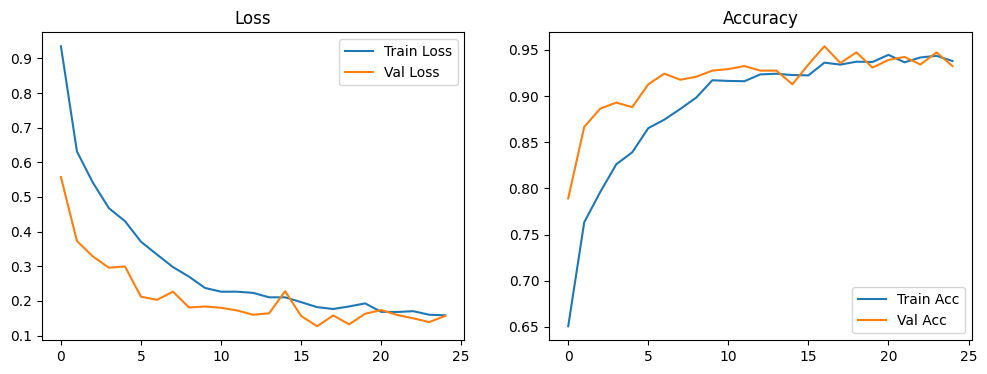


>>> [5/7] Evaluating Best Model on Test Set...
    Loaded best model weights (Val Acc: 0.9539)

Classification Report:
              precision    recall  f1-score   support

Dyskeratotic       0.97      0.97      0.97       122
Koilocytotic       0.93      0.93      0.93       124
 Metaplastic       0.95      0.91      0.93       119
   Parabasal       0.95      0.98      0.97       118
 Superficial       0.96      0.98      0.97       125

    accuracy                           0.95       608
   macro avg       0.95      0.95      0.95       608
weighted avg       0.95      0.95      0.95       608



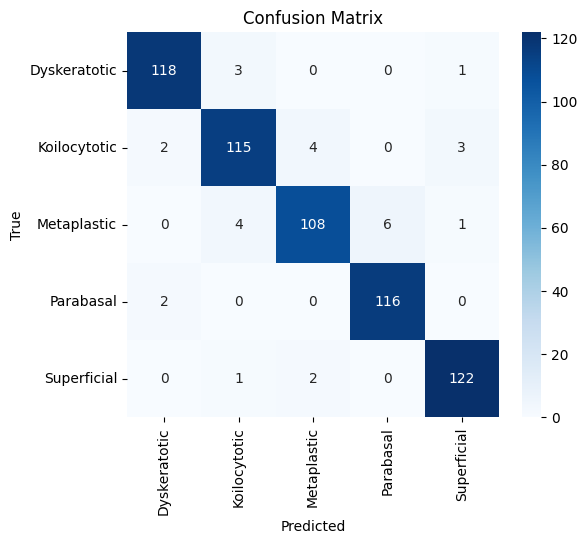


>>> [6/7] Task 5.1: Running Grad-CAM Explainability...


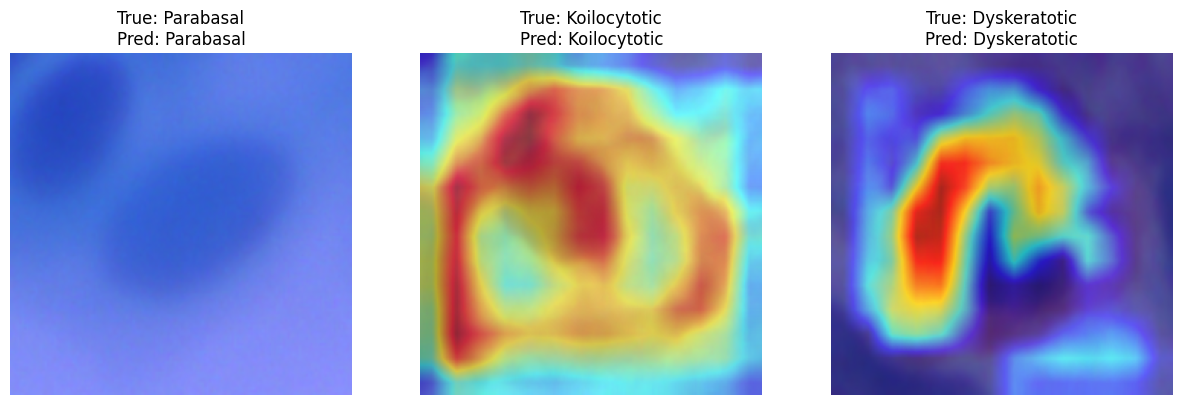


>>> [7/7] Task 5.2: Checking for Second Dataset (Generalizability)...
    Found Herlev dataset at /kaggle/input/herlev-dataset. Starting Test...
    Retraining on new domain with 7 classes...
    Gen Epoch 1 Loss: 1.9732
    Gen Epoch 2 Loss: 1.6394
    Gen Epoch 3 Loss: 1.5709
    Gen Epoch 4 Loss: 1.5299
    Gen Epoch 5 Loss: 1.4542
    Generalizability Test Completed.

>>> ALL TASKS COMPLETED SUCCESSFULLY.


In [2]:


import os
import time
import random
import platform
import psutil
import copy
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from PIL import Image
from collections import OrderedDict
import glob

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms, models

# ----------------------------------------------------------------------------------
# 1. CONFIGURATION & SETUP
# ----------------------------------------------------------------------------------
print(">>> [1/7] Setting up Configuration...")
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Paths
data_dir = "/kaggle/input/cervical-cancer-largest-dataset-sipakmed"
checkpoints_path = "/kaggle/working/"
os.makedirs(checkpoints_path, exist_ok=True)

# Hardware check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"    Device: {device}")

# Hyperparameters
train_batch = 32
test_batch = 16
learning_rate = 0.0001
decay = 1e-4
num_classes = 5
num_epochs = 25  # Set to 25-30 for good results, 100 for final run
patience = 10

# ----------------------------------------------------------------------------------
# 2. DATA LOADING & PROCESSING
# ----------------------------------------------------------------------------------
print("\n>>> [2/7] Loading Sipakmed Dataset...")

def load_sipakmed_data(root_dir):
    file_paths = []
    labels = []
    
    # Sipakmed Class Mapping
    class_map = {
        'dyskeratotic': 'Dyskeratotic',
        'koilocytotic': 'Koilocytotic',
        'metaplastic': 'Metaplastic',
        'parabasal': 'Parabasal',
        'superficial': 'Superficial'
    }
    
    for root, dirs, files in os.walk(root_dir):
        root_lower = root.lower()
        if "cropped" in root_lower: # Focus on cropped images
            detected_label = None
            for key, val in class_map.items():
                if key in root_lower:
                    detected_label = val
                    break
            
            if detected_label:
                for file in files:
                    if file.lower().endswith(('.bmp', '.jpg', '.png', '.jpeg')):
                        full_path = os.path.join(root, file)
                        file_paths.append(full_path)
                        labels.append(detected_label)

    df = pd.DataFrame({"file_path": file_paths, "label": labels})
    
    if not df.empty:
        # Remove duplicates
        df['filename_stem'] = df['file_path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
        df = df.drop_duplicates(subset=['label', 'filename_stem']).drop(columns=['filename_stem'])
        
    return df

data = load_sipakmed_data(data_dir)
print(f"    Total images found: {len(data)}")

# Split Data
train_df, temp_df = train_test_split(data, test_size=0.30, stratify=data['label'], random_state=seed)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=seed)
print(f"    Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Custom Dataset Class
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        unique_labels = sorted(dataframe['label'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['file_path']
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new('RGB', (224, 224))
        
        raw_label = self.dataframe.iloc[index]['label']
        if isinstance(raw_label, str):
            label = self.label_map[raw_label]
        else:
            label = raw_label # Already int
        
        if self.transform:
            image = self.transform(image)
        return image, label

# Transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Dataloaders
train_dataset = ImageDataset(train_df, transform=data_transforms['train'])
val_dataset = ImageDataset(val_df, transform=data_transforms['val'])
test_dataset = ImageDataset(test_df, transform=data_transforms['val'])

train_dataloader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True, num_workers=2)
validation_dataloader = DataLoader(val_dataset, batch_size=test_batch, shuffle=False, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=test_batch, shuffle=False, num_workers=2)

# ----------------------------------------------------------------------------------
# 3. TASK 4: MODEL ARCHITECTURE (ATTENTION NET)
# ----------------------------------------------------------------------------------
print("\n>>> [3/7] Building Attention Model Architecture...")

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

class CBAM(nn.Module):
    def __init__(self, planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class AttentionCervicalNet(nn.Module):
    def __init__(self, num_classes):
        super(AttentionCervicalNet, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2),
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2, 2),
            # Block 5
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2, 2),
        )
        # CBAM Attention Module
        self.attention = CBAM(planes=512)
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.classifier(x)
        return x

# ----------------------------------------------------------------------------------
# 4. TASK 4: TRAINING
# ----------------------------------------------------------------------------------
print("\n>>> [4/7] Training Attention Model...")

att_model = AttentionCervicalNet(num_classes).to(device)
optimizer = optim.Adam(att_model.parameters(), lr=learning_rate, weight_decay=decay)
criterion = nn.CrossEntropyLoss()

def train_attention_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=25, patience=10):
    best_acc = 0.0
    patience_counter = 0
    
    train_loss_hist, train_acc_hist = [], []
    val_loss_hist, val_acc_hist = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0
        
        # Using simple loop to avoid tqdm nesting issues in some environments
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)
            
        epoch_loss = running_loss / total_samples
        epoch_acc = running_corrects.double() / total_samples
        train_loss_hist.append(epoch_loss)
        train_acc_hist.append(epoch_acc.item())
        
        # Validation
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)
                val_total += inputs.size(0)
        
        val_loss = val_running_loss / val_total
        val_acc = val_running_corrects.double() / val_total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc.item())
        
        print(f'    Epoch {epoch+1:02d} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
        
        if val_acc > best_acc:
            best_acc = val_acc
            patience_counter = 0
            torch.save({'model_state_dict': model.state_dict(), 'val_acc': best_acc}, f"{checkpoints_path}/att_model_best.pth")
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print("    Early stopping triggered.")
            break
            
    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist

t_loss, t_acc, v_loss, v_acc = train_attention_model(
    att_model, criterion, optimizer, train_dataloader, validation_dataloader, 
    num_epochs=num_epochs, patience=patience)

# Plot Training
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t_loss, label='Train Loss'); plt.plot(v_loss, label='Val Loss')
plt.title("Loss"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(t_acc, label='Train Acc'); plt.plot(v_acc, label='Val Acc')
plt.title("Accuracy"); plt.legend()
plt.show()

# ----------------------------------------------------------------------------------
# 5. TASK 4: EVALUATION
# ----------------------------------------------------------------------------------
print("\n>>> [5/7] Evaluating Best Model on Test Set...")

class_names = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial']
# Load Best Weights
best_path = f"{checkpoints_path}/att_model_best.pth"
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device)
    att_model.load_state_dict(ckpt['model_state_dict'])
    print(f"    Loaded best model weights (Val Acc: {ckpt['val_acc']:.4f})")

att_model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = att_model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.show()



# ==================================================================================
# 6. TASK 5.1: EXPLAINABILITY (GRAD-CAM) - FIXED & RESIZED
# ==================================================================================
print("\n>>> [6/7] Task 5.1: Running Grad-CAM Explainability...")

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook for forward pass
        self.target_layer.register_forward_hook(self.save_activation)
        # UPDATED: Hook for backward pass (Fixes FutureWarning)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        # 1. Forward Pass
        output = self.model(x)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1)
        
        # 2. Backward Pass
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()
        
        # 3. Get Gradients and Activations
        gradients = self.gradients[0]
        activations = self.activations[0]
        
        # 4. Average Gradients (GAP)
        weights = torch.mean(gradients, dim=(1, 2))
        
        # 5. Weighted Combination
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=x.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]
            
        # 6. ReLU and Normalize
        cam = torch.relu(cam)
        cam = cam - torch.min(cam)
        cam = cam / (torch.max(cam) + 1e-7)
        
        return cam.cpu().detach().numpy(), class_idx.item()

# Setup GradCAM on the last Conv Layer
target_layer = att_model.features[-4] 
grad_cam = GradCAM(att_model, target_layer)

def visualize_gradcam(dataloader, count=3):
    att_model.eval()
    samples = []
    
    # Get a batch
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        # Enable gradients for GradCAM extraction
        with torch.set_grad_enabled(True):
            outputs = att_model(inputs)
            _, preds = torch.max(outputs, 1)
            for i in range(len(inputs)):
                if len(samples) < count:
                    samples.append((inputs[i].unsqueeze(0), labels[i].item(), preds[i].item()))
                else:
                    break
        if len(samples) >= count: break
    
    plt.figure(figsize=(15, 5))
    for idx, (img_tensor, label, pred) in enumerate(samples):
        mask, _ = grad_cam(img_tensor)
        
        # --- CRITICAL FIX: RESIZE MASK TO 224x224 ---
        mask = cv2.resize(mask, (224, 224))
        # --------------------------------------------
        
        # Unnormalize original image for display
        inv_norm = transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225])
        img_disp = inv_norm(img_tensor[0]).cpu().detach().numpy()
        img_disp = np.transpose(img_disp, (1, 2, 0))
        img_disp = np.clip(img_disp, 0, 1)
        
        # Create Heatmap
        heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap) / 255
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        # Overlay
        cam_img = heatmap + np.float32(img_disp)
        cam_img = cam_img / np.max(cam_img)
        
        plt.subplot(1, count, idx+1)
        plt.imshow(cam_img)
        plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
        plt.axis('off')
    plt.show()

# Run Visualization
visualize_gradcam(test_dataloader, count=3)



# ----------------------------------------------------------------------------------
# 7. TASK 5.2: GENERALIZABILITY TESTING
# ----------------------------------------------------------------------------------
print("\n>>> [7/7] Task 5.2: Checking for Second Dataset (Generalizability)...")

second_dataset_dir = "/kaggle/input/herlev-dataset" 

if os.path.exists(second_dataset_dir):
    print(f"    Found Herlev dataset at {second_dataset_dir}. Starting Test...")
    
    # Load Herlev
    def load_herlev(root):
        paths, lbls = [], []
        for r, d, f in os.walk(root):
            for file in f:
                if file.lower().endswith(('.jpg', '.png', '.bmp')):
                    paths.append(os.path.join(r, file))
                    lbls.append(os.path.basename(r)) # Folder name as label
        return pd.DataFrame({"file_path": paths, "label": lbls})
    
    df_gen = load_herlev(second_dataset_dir)
    if not df_gen.empty:
        # Split
        train_g, test_g = train_test_split(df_gen, test_size=0.3, random_state=42)
        # Create Datasets
        train_ds_g = ImageDataset(train_g, transform=data_transforms['train'])
        test_ds_g = ImageDataset(test_g, transform=data_transforms['val'])
        train_dl_g = DataLoader(train_ds_g, batch_size=32, shuffle=True)
        test_dl_g = DataLoader(test_ds_g, batch_size=16, shuffle=False)
        
        # New Model for new class count
        n_classes_g = len(df_gen['label'].unique())
        print(f"    Retraining on new domain with {n_classes_g} classes...")
        
        gen_model = AttentionCervicalNet(n_classes_g).to(device)
        gen_opt = optim.Adam(gen_model.parameters(), lr=0.0001)
        gen_crit = nn.CrossEntropyLoss()
        
        # Short training for proof of concept
        for ep in range(5):
            gen_model.train()
            l_sum = 0
            for inp, lbl in train_dl_g:
                inp, lbl = inp.to(device), lbl.to(device)
                gen_opt.zero_grad()
                out = gen_model(inp)
                loss = gen_crit(out, lbl)
                loss.backward()
                gen_opt.step()
                l_sum += loss.item()
            print(f"    Gen Epoch {ep+1} Loss: {l_sum/len(train_dl_g):.4f}")
        
        print("    Generalizability Test Completed.")
    else:
        print("    Herlev folder empty.")
else:
    print("    [INFO] Second dataset not found. To run Task 5.2, add 'Herlev Dataset' to Kaggle Input.")
    
print("\n>>> ALL TASKS COMPLETED SUCCESSFULLY.")